Total no. of qubits required is  8
Grover operator : no. of iteration 2
printing the quantum circuit:


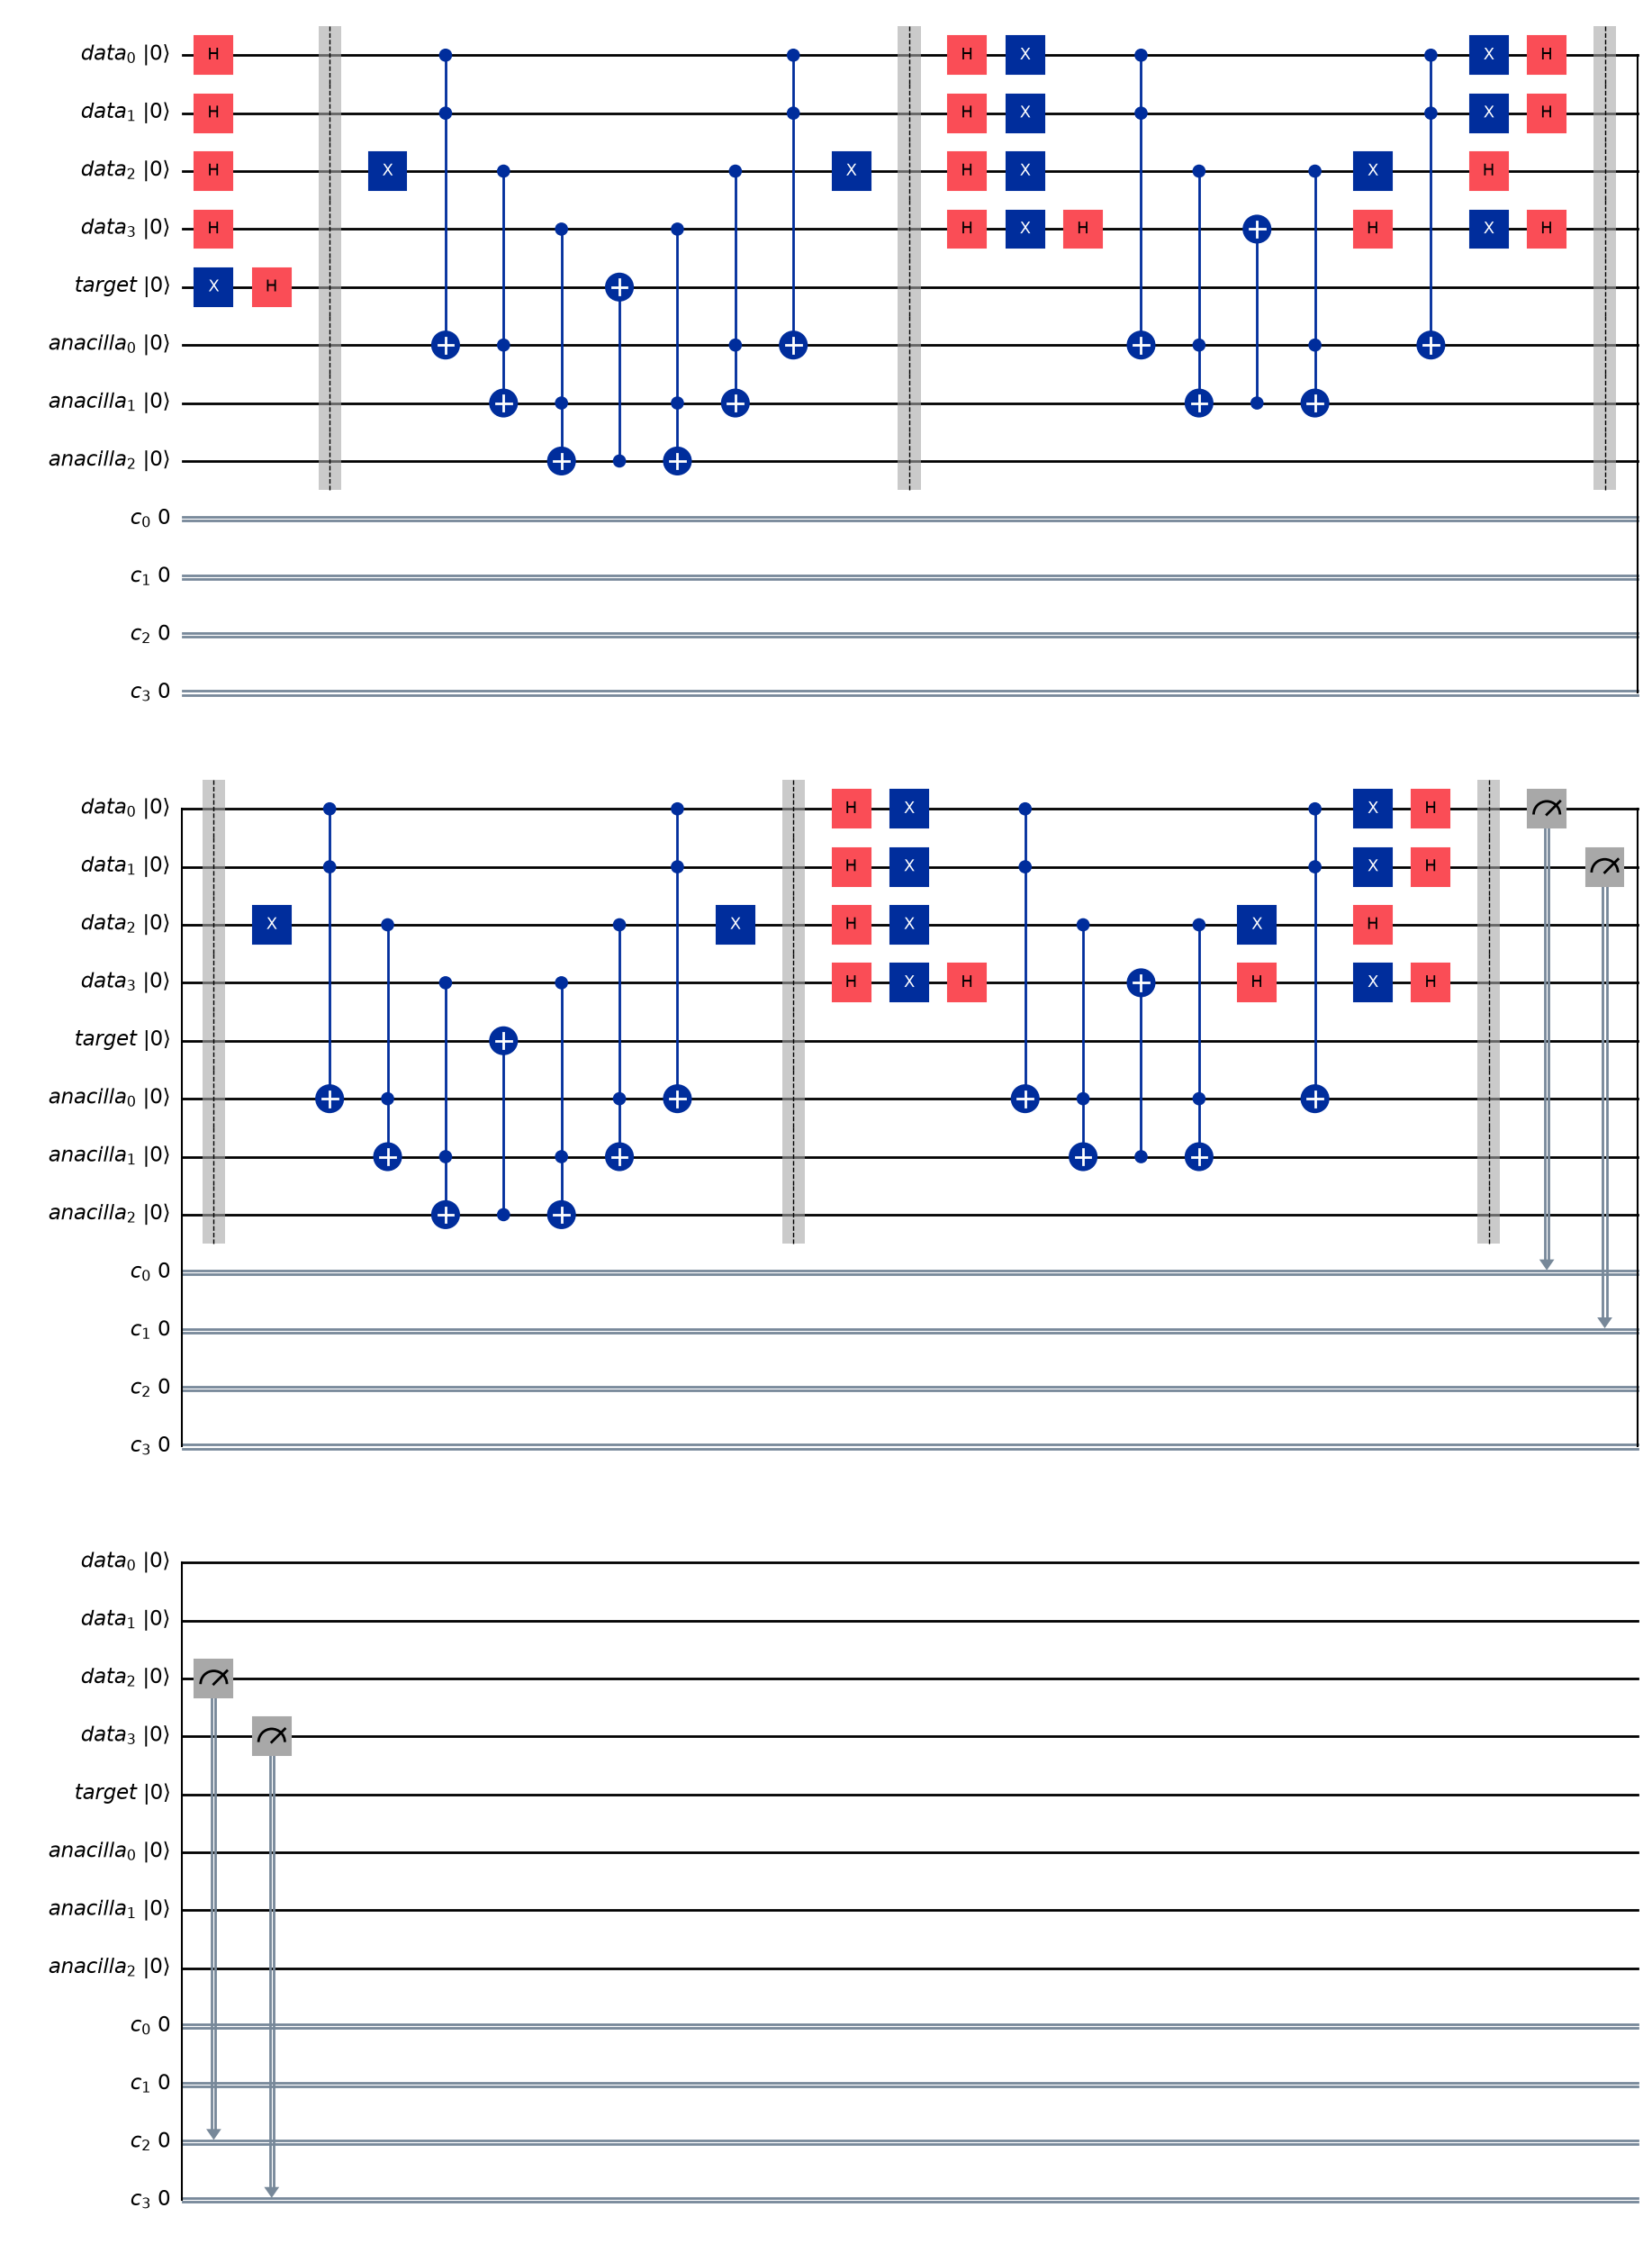

In [1]:
# this code will run of qiskit version > 1.0
# to run this code in lower version, you have to set up qiskit_aer library into same environment. 
# better to implement on qiskit version >1.0
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit import *
from qiskit import transpile
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
import math
import matplotlib.pyplot as plt
import numpy as np

n=4
#n=int(float(input("please enter the no of bit:")))
print("Total no. of qubits required is ",2*n)

arr=[3]


### taking total number of data qubit
q = QuantumRegister(n, 'data')

### target qubit
t = QuantumRegister(1, 'target')

### total number of anacialla qubit which is n-1
anc = QuantumRegister(n-1, 'anacilla')

### taking classical register for the measurement
c = ClassicalRegister(n, 'c')
circuit = QuantumCircuit(q,t,anc,c)


###initializing the circuit but putting hadamard gate (making super position of input data)
for i in range(n):
    circuit.h(q[i])
circuit.x(t[0])
circuit.h(t[0])



###initializing the array for oracle designing
res=[i for i in range(n)]
noofiter=math.ceil(math.sqrt(n)*math.pi/4)
print("Grover operator : no. of iteration", noofiter)
# no of time grover diffusion operator are applied are calculated by this fucntion math.ceil(math.sqrt(n)*math.pi/4)
for i in range(math.ceil(math.sqrt(n)*math.pi/4)):
    ### creating circuit barirer for clear illustration
    circuit.barrier()
    ###applying X Gate to the oracle if any input given by the user
    if len(arr)!=0:
        for i in arr:
            circuit.x(q[i-1])
    # creating oracle 
    for i in range(len(res)-1):
        if i==0:
            circuit.ccx(q[res[i]], q[res[i+1]], anc[i])
        else:
            circuit.ccx(q[res[i+1]], anc[i-1], anc[i])
    circuit.cx(anc[i],t[0])
    for i in range(len(res)-1,0,-1):
        if i==1:
            circuit.ccx(q[res[i-1]], q[res[i]], anc[i-1])
        else:
            circuit.ccx(q[res[i]], anc[i-2], anc[i-1])
    ### removing X gate from the Oracle       
    if len(arr)!=0:
        for i in arr:
            circuit.x(q[i-1])     
    circuit.barrier()
    
        
       
    ### creating reflcetion operator
    
    ### applying the Hadamard Gate
    for i in range(n):
        circuit.h(q[i])   
    ### applying the X Gate
    for i in range(n):
        circuit.x(q[i])
    circuit.h(q[-1])
    
    for i in range(len(res)-2):
        if i==0:
            circuit.ccx(q[res[i]], q[res[i+1]], anc[i])
        else:
            circuit.ccx(q[res[i+1]], anc[i-1], anc[i])
    circuit.cx(anc[i],q[n-1])
    for i in range(len(res)-2,0,-1):
        if i==1:
            circuit.ccx(q[res[i-1]], q[res[i]], anc[i-1])
        else:
            circuit.ccx(q[res[i]], anc[i-2], anc[i-1])      
    circuit.h(q[-1])
    for i in range(n):
        circuit.x(q[i])    
        circuit.h(q[i])
    #circuit.h(q[-1])
    circuit.barrier()
            
        
# taking measurement
for i in range(n):
    circuit.measure(q[i],c[i])
            
print("printing the quantum circuit:")   
circuit.draw(initial_state=True, cregbundle=False, output='mpl')   
    
      
    
    


{'0011': 5, '0001': 7, '1010': 3, '0111': 11, '1111': 3, '1101': 10, '0110': 6, '1100': 5, '0100': 8, '0010': 8, '0000': 8, '1110': 4, '1000': 5, '1001': 11, '1011': 906}
displaying the histogram


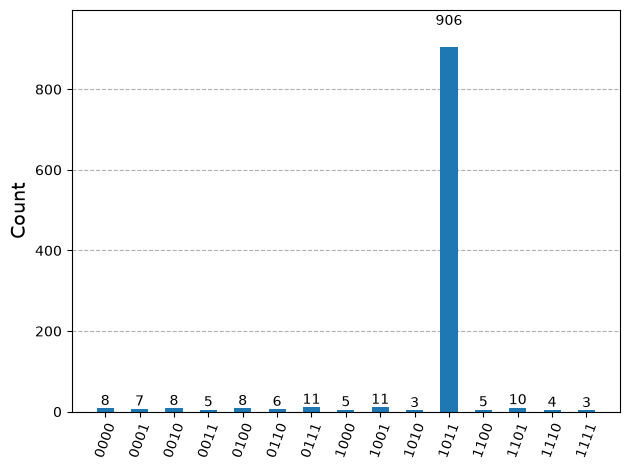

In [2]:
#chosing backend and executing job
shot=1000
#shot=int(float(input("please enter the number of shorts:")))
backend = AerSimulator()
    
    # First we have to transpile the quantum circuit 
    # to the low-level QASM instructions used by the 
    # backend
qc_compiled = transpile(circuit, backend)
    
    # Execute the circuit on the qasm simulator.
    # We've set the number of repeats of the circuit
    # to be 1024, which is the default.
job_sim = backend.run(qc_compiled, shots=shot)
    
    # Grab the results from the job.
result_sim = job_sim.result()
    
counts = result_sim.get_counts(qc_compiled)
print(counts)
print("displaying the histogram")
plot_histogram(counts)

In [3]:
### value that appear highest time
x=0
y=0
for i in counts.items():
    if y<int(i[1]):
        x=i[0]
        y=int(i[1])
print("Grover search result is :",x)

Grover search result is : 1011
